<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
from google.colab import drive
import os

# Монтируем Google Drive
drive.mount('/content/drive')

# Определяем путь к изображениям (изображения уже предварительно были сжаты до 256x256)
# если нужны будут уменьшенные копии изображений, то можете скачать (~334Mb):
# https://drive.google.com/file/d/1cxLoLJrfyvX2E7RVQMox5kTPUgCkbMH1/
extract_path = '/content/drive/MyDrive/DLS/DLS_1/HW8/faces_dataset_small_256'

Mounted at /content/drive


In [3]:
def get_dataloader(image_size=256, batch_size=32):
    """
    Функция строит DataLoader для изображений
    """
    transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor(),
        tt.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # Загружаем картинки с диска
    dataset = ImageFolder(root=os.path.dirname(extract_path), transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    return loader

In [4]:
image_size = 128
batch_size = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader = get_dataloader(image_size, batch_size)

print(f"Device: {device}")
if train_loader:
    print(f"Dataset size: {len(train_loader.dataset)} images")

Device: cuda
Dataset size: 3143 images


## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [5]:
discriminator = nn.Sequential(
    # input is (3) x 128 x 128
    nn.Conv2d(3, 64, 4, 2, 1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    # state size. (64) x 64 x 64
    nn.Conv2d(64, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # state size. (128) x 32 x 32
    nn.Conv2d(128, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # state size. (256) x 16 x 16
    nn.Conv2d(256, 512, 4, 2, 1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # state size. (512) x 8 x 8
    nn.Conv2d(512, 1024, 4, 2, 1, bias=False),
    nn.BatchNorm2d(1024),
    nn.LeakyReLU(0.2, inplace=True),
    # state size. (1024) x 4 x 4
    nn.Conv2d(1024, 1, 4, 1, 0, bias=False),
    nn.Sigmoid()
).to(device)

In [6]:
latent_size = 128

generator = nn.Sequential(
    # input is Z, going into a convolution
    nn.ConvTranspose2d(latent_size, 1024, 4, 1, 0, bias=False),
    nn.BatchNorm2d(1024),
    nn.ReLU(True),
    # state size. (1024) x 4 x 4
    nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # state size. (512) x 8 x 8
    nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # state size. (256) x 16 x 16
    nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # state size. (128) x 32 x 32
    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # state size. (64) x 64 x 64
    nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
    nn.Tanh()
    # state size. (3) x 128 x 128
).to(device)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [7]:
lr = 0.0002

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

optimizer = {
    "discriminator": torch.optim.Adam(model["discriminator"].parameters(), lr=lr, betas=(0.5, 0.999)),
    "generator": torch.optim.Adam(model["generator"].parameters(), lr=lr, betas=(0.5, 0.999))
}

In [8]:
def fit(model, criterion, epochs, train_loader):
    # Списки для хранения лоссов
    losses_d = []
    losses_g = []

    for epoch in range(epochs):
        loss_g_running = 0.0
        loss_d_running = 0.0

        for real_images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            ##############################
            #   Обучение Дискриминатора
            ##############################
            optimizer['discriminator'].zero_grad()

            # Реальные изображения (Метка 1)
            labels_real = torch.ones(batch_size, 1, 1, 1).to(device)
            output_real = model['discriminator'](real_images)
            loss_d_real = criterion['discriminator'](output_real, labels_real)

            # Фейковые изображения (Метка 0)
            noise = torch.randn(batch_size, latent_size, 1, 1).to(device)
            fake_images = model['generator'](noise)
            labels_fake = torch.zeros(batch_size, 1, 1, 1).to(device)
            output_fake = model['discriminator'](fake_images.detach())
            loss_d_fake = criterion['discriminator'](output_fake, labels_fake)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer['discriminator'].step()

            ##########################
            #   Обучение Генератора
            ##########################
            optimizer['generator'].zero_grad()
            output_g = model['discriminator'](fake_images)

            loss_g = criterion['generator'](output_g, labels_real)
            loss_g.backward()
            optimizer['generator'].step()

            loss_d_running += loss_d.item()
            loss_g_running += loss_g.item()

        # Сохраняем средние лоссы за эпоху
        losses_d.append(loss_d_running / len(train_loader))
        losses_g.append(loss_g_running / len(train_loader))

        print(f"Epoch [{epoch+1}/{epochs}] Loss_D: {losses_d[-1]:.4f}, Loss_G: {losses_g[-1]:.4f}")

    return losses_d, losses_g

In [9]:
epochs = 25

# Обучаем
losses_g, losses_d = fit(model, criterion, epochs, train_loader)

Epoch 1/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [1/25] Loss_D: 1.0047, Loss_G: 13.9272


Epoch 2/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [2/25] Loss_D: 0.7009, Loss_G: 7.4142


Epoch 3/25:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch [23/25] Loss_D: 1.0560, Loss_G: 3.4983


Epoch 24/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [24/25] Loss_D: 0.9562, Loss_G: 3.5225


Epoch 25/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [25/25] Loss_D: 0.9831, Loss_G: 3.4205


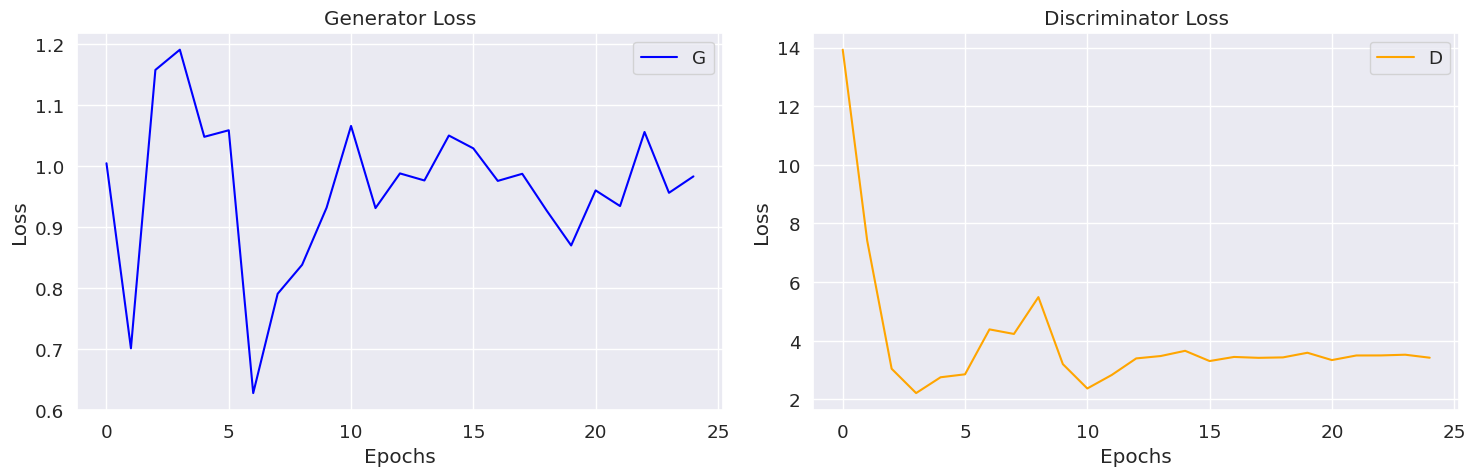

In [10]:
# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График для Генератора
ax1.plot(losses_g, label="G", color='blue')
ax1.set_title("Generator Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()

# График для Дискриминатора
ax2.plot(losses_d, label="D", color='orange')
ax2.set_title("Discriminator Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

В первые 5 эпох наблюдается резкий рост лосса генератора и падение лосса дискриминатора. Это ожидаемо: дискриминатор быстро учится отличать шум от реальных лиц, а генератору требуется время, чтобы начать создавать правдоподобные структуры.  

Примерно с 10-й эпохи, оба лосса вышли на плато. Однако ни один лосс не ушёл в  ноль или бесконечность, а продолжают немного колебаться, т.е. между сетями сохраняется некоторая здоровая конкуренция.

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [21]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

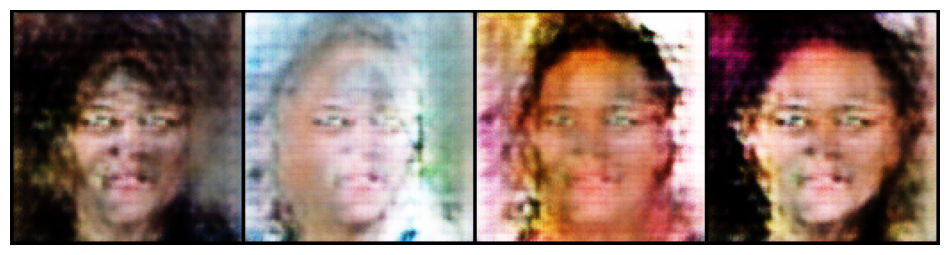

In [22]:
def show_images(generated):
    grid = make_grid(generated, nrow=4, normalize=True).cpu().permute(1, 2, 0).numpy()

    plt.figure(figsize=(12, 8))
    plt.imshow(grid)
    plt.axis('off')
    plt.show()

show_images(fake_images)

Как вам качество получившихся изображений?

Нууууу, в целом неплохо (для 2001 года :) )   
Из плюсов: генератор успешно выучил базовую структуру лица, на изображениях четко прослеживается контур лица, глаза, нос, брови, волосы и рот, и всё на своих местах, т.е. соблюдены пропорции лица. Все лица получились разными.  
Минусы: изображение всё-таки далеко от реального, видны артефакты присущие сгенерированным изображениям, на всех изображениях генератор не смог в высокую детализации деталей.

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
import numpy as np
import torch

# Подготовка данных
n_subset = 500  # уменьшил размер выборки, т.к. на полном объеме данных не дождался результата
generator.eval()

# Отбираем случайные 500 индексов и достаем соответствующие реальные изображения
all_reals_indices = np.random.choice(len(train_loader.dataset), n_subset, replace=False)
reals = np.array([train_loader.dataset[i][0].numpy() for i in all_reals_indices])

# Генерируем 500 фейковых изображений
fakes_list = []
with torch.no_grad():
    for _ in range(0, n_subset, batch_size):
        current_batch_size = min(batch_size, n_subset - len(fakes_list)*batch_size)
        if current_batch_size <= 0: break
        z = torch.randn(current_batch_size, latent_size, 1, 1).to(device)
        gen_imgs = generator(z).cpu().numpy()
        fakes_list.append(gen_imgs)
fakes = np.concatenate(fakes_list, axis=0)[:n_subset]

# Конкатенация и создание меток (500 реальных + 500 фейковых)
X_data = np.concatenate([reals.reshape(n_subset, -1), fakes.reshape(n_subset, -1)])
y_data = np.concatenate([np.ones(n_subset), np.zeros(n_subset)])

# Расчет 1-NN Accuracy через Leave-One-Out
clf = KNeighborsClassifier(n_neighbors=1)
loo = LeaveOneOut()
scores = cross_val_score(clf, X_data, y_data, cv=loo, n_jobs=-1)
acc = scores.mean()

print(f"1-NN Accuracy: {acc:.4f}")

1-NN Accuracy: 0.9240


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

**Что вы можете сказать о получившемся результате?**
Значение accuracy = 0.9240  
Такое высокое значение означает, что распределения реальных и сгенерированных данных все еще сильно различаются. Классификатор легко находит отличия, а значит, генератор пока не научился полностью имитировать структуру реальных данных (это мы как раз и видели на примерах).

**Какой accuracy мы хотели бы получить?**  
Хотелось бы получить значение близкое к 0.5, это бы означало, что классификатор угадывает класс случайно, а значит наш генератор научился создавать изображения не отличимые от реальных.

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


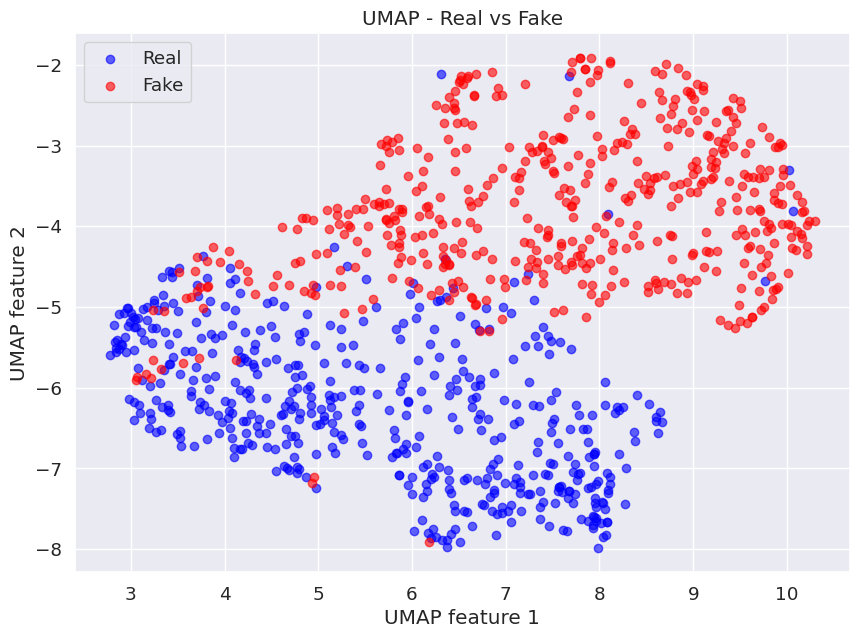

In [26]:
!pip install -q umap-learn
import umap

# помимо t-SNE захотелось посмотреть на снижение размерности с помощью UMAP
n_samples = 500
idx_reals = np.random.choice(len(reals), n_samples, replace=False)
idx_fakes = np.random.choice(len(fakes), n_samples, replace=False)

X_subset = np.concatenate([reals[idx_reals].reshape(n_samples, -1),
                           fakes[idx_fakes].reshape(n_samples, -1)])
y_subset = np.concatenate([np.ones(n_samples), np.zeros(n_samples)])

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_subset)

# Визуализация
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[y_subset==1, 0], X_umap[y_subset==1, 1], c='blue', label='Real', alpha=0.6)
plt.scatter(X_umap[y_subset==0, 0], X_umap[y_subset==0, 1], c='red', label='Fake', alpha=0.6)
plt.legend()
plt.title("UMAP - Real vs Fake")
plt.xlabel("UMAP feature 1")
plt.ylabel("UMAP feature 2")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


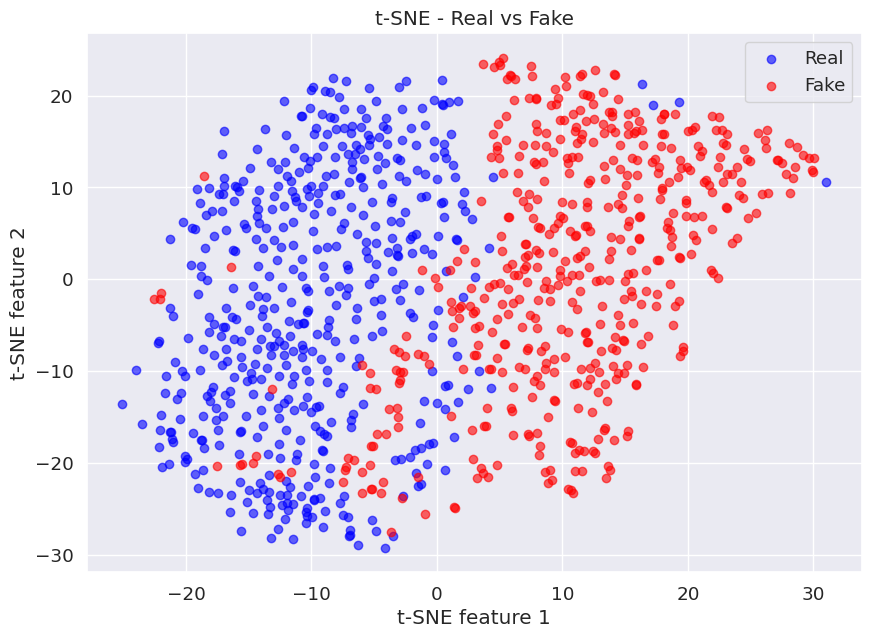

In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_subset)

# Визуализация t-SNE
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[y_subset==1, 0], X_tsne[y_subset==1, 1], c='blue', label='Real', alpha=0.6)
plt.scatter(X_tsne[y_subset==0, 0], X_tsne[y_subset==0, 1], c='red', label='Fake', alpha=0.6)
plt.legend()
plt.title("t-SNE - Real vs Fake")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.show()

Прокомментируйте получившийся результат:

Глядя на графики отчётливо видно, что реальные и фейковые изображения легко разделимы: группы точек легко разделяются, что собственно мы и увидели по метрике accuracy.  
Как только точки начнут перекрываться друг другом, тогда можно будет говорить о том, что наш генератор научился создавать изображения трудноотличимые от реальных.